# Trader Behavior vs Market Sentiment

This notebook completes **Part A, B, and C**:
- Data preparation and quality checks
- Fear vs Greed performance/behavior analysis
- Trader segmentation and actionable strategy rules

Outputs (charts) are saved to the `charts/` folder.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", 100)

base_dir = Path.cwd()
if not (base_dir / "Datasets").exists():
    base_dir = Path("c:/Users/HP/Desktop/Trader-Sentiment-Analysis")

data_dir = base_dir / "Datasets"
charts_dir = base_dir / "charts"
charts_dir.mkdir(parents=True, exist_ok=True)

fear_path = data_dir / "fear_greed_index.csv"
trades_path = data_dir / "historical_data.csv"

print("Base dir:", base_dir)
print("Data files found:", fear_path.exists(), trades_path.exists())

Base dir: c:\Users\HP\Desktop\Trader-Sentiment-Analysis
Data files found: True True


In [ ]:
fear = pd.read_csv(fear_path)
trades = pd.read_csv(trades_path)

print("Fear/Greed shape:", fear.shape)
print("Trades shape:", trades.shape)
print("Fear duplicates:", fear.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())

fear["date"] = pd.to_datetime(fear["date"], errors="coerce").dt.date
fear["value"] = pd.to_numeric(fear["value"], errors="coerce")

ts_ist = pd.to_datetime(trades["Timestamp IST"], dayfirst=True, errors="coerce")
ts_epoch = pd.to_datetime(pd.to_numeric(trades["Timestamp"], errors="coerce"), unit="ms", errors="coerce")
trades["trade_date"] = ts_ist.fillna(ts_epoch).dt.date

numeric_cols = ["Execution Price", "Size Tokens", "Size USD", "Start Position", "Closed PnL", "Fee"]
trades[numeric_cols] = trades[numeric_cols].apply(pd.to_numeric, errors="coerce")
trades = trades.dropna(subset=["trade_date", "Account"]).drop_duplicates().copy()

merged = trades.merge(
    fear[["date", "classification", "value"]],
    left_on="trade_date",
    right_on="date",
    how="left",
)

sent = merged["classification"].fillna("").str.lower()
merged["sentiment_bucket"] = np.select(
    [sent.str.contains("fear"), sent.str.contains("greed"), sent.str.contains("neutral")],
    ["Fear", "Greed", "Neutral"],
    default="Unknown",
)

print("Sentiment merge coverage:", f"{merged['classification'].notna().mean():.2%}")
print("Merged shape:", merged.shape)

Fear/Greed shape: (2644, 4)
Trades shape: (211224, 16)

--- Missing values (top 10) ---
Fear:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades:
 Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Timestamp IST      0
Start Position     0
Direction          0
Closed PnL         0
dtype: int64

--- Duplicates ---
Fear duplicates: 0
Trades duplicates: 0

Sentiment merge coverage: 100.00%
Unique sentiment labels: ['Extreme Fear', 'Extreme Greed', 'Fear', 'Greed', 'Neutral']

Merged shape: (211224, 22)


## Part A — Key Metrics Creation

We compute daily trader/account metrics and daily market-level metrics aligned with sentiment by date.

In [ ]:
merged["is_long"] = merged["Side"].astype(str).str.upper().eq("BUY").astype(int)
merged["is_win"] = merged["Closed PnL"].fillna(0).gt(0).astype(int)

merged["leverage_proxy"] = (
    merged["Size USD"].abs() / merged["Start Position"].abs().replace(0, np.nan)
)
merged["leverage_proxy"] = merged["leverage_proxy"].clip(
    upper=merged["leverage_proxy"].quantile(0.99)
)

daily_account = merged.groupby(["trade_date", "Account", "sentiment_bucket"], as_index=False).agg(
    daily_pnl=("Closed PnL", "sum"),
    win_rate=("is_win", "mean"),
    avg_trade_size=("Size USD", "mean"),
    avg_leverage=("leverage_proxy", "mean"),
    trades_per_day=("Trade ID", "count"),
    long_ratio=("is_long", "mean"),
)

daily_market = merged.groupby(["trade_date", "sentiment_bucket"], as_index=False).agg(
    daily_pnl=("Closed PnL", "sum"),
    win_rate=("is_win", "mean"),
    avg_trade_size=("Size USD", "mean"),
    avg_leverage=("leverage_proxy", "mean"),
    trades_per_day=("Trade ID", "count"),
    long_short_ratio=("is_long", "mean"),
)

daily_market = daily_market.sort_values("trade_date").copy()
daily_market["cum_pnl"] = daily_market["daily_pnl"].cumsum()
daily_market["drawdown_proxy"] = daily_market["cum_pnl"] - daily_market["cum_pnl"].cummax()

print("Daily account metrics shape:", daily_account.shape)
print("Daily market metrics shape:", daily_market.shape)
display(daily_account.head())
display(daily_market.head())

Daily account metrics shape: (2341, 9)
Daily market metrics shape: (480, 10)


,trade_date,Account,sentiment_bucket,daily_pnl,win_rate,avg_trade_size,avg_leverage,trades_per_day,long_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,0.000000,159.000000,1191.326187,3,1.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,0.000000,5556.203333,10886.501280,9,0.777778
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,0.363636,10291.213636,5157.787935,11,0.818182
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,0.000000,5304.975000,2.428007,2,1.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,0.000000,5116.256667,0.315058,3,1.000000


,trade_date,sentiment_bucket,daily_pnl,win_rate,avg_trade_size,avg_leverage,trades_per_day,long_short_ratio,cum_pnl,drawdown_proxy
0,2023-05-01,Greed,0.000000,0.000000,159.000000,1191.326187,3,1.000000,0.000000,0.000000
1,2023-12-05,Greed,0.000000,0.000000,5556.203333,10886.501280,9,0.777778,0.000000,0.000000
2,2023-12-14,Greed,-205.434737,0.363636,10291.213636,5157.787935,11,0.818182,-205.434737,-205.434737
3,2023-12-15,Greed,-24.632034,0.000000,5304.975000,2.428007,2,1.000000,-230.066771,-230.066771
4,2023-12-16,Greed,0.000000,0.000000,5116.256667,0.315058,3,1.000000,-230.066771,-230.066771


,days,mean_daily_pnl,median_daily_pnl,mean_win_rate,mean_drawdown_proxy
sentiment_bucket,,,,,
Fear,105,39012.054192,1876.812082,0.328876,-37928.897203
Greed,307,15847.884637,1008.619956,0.384793,-13671.286124


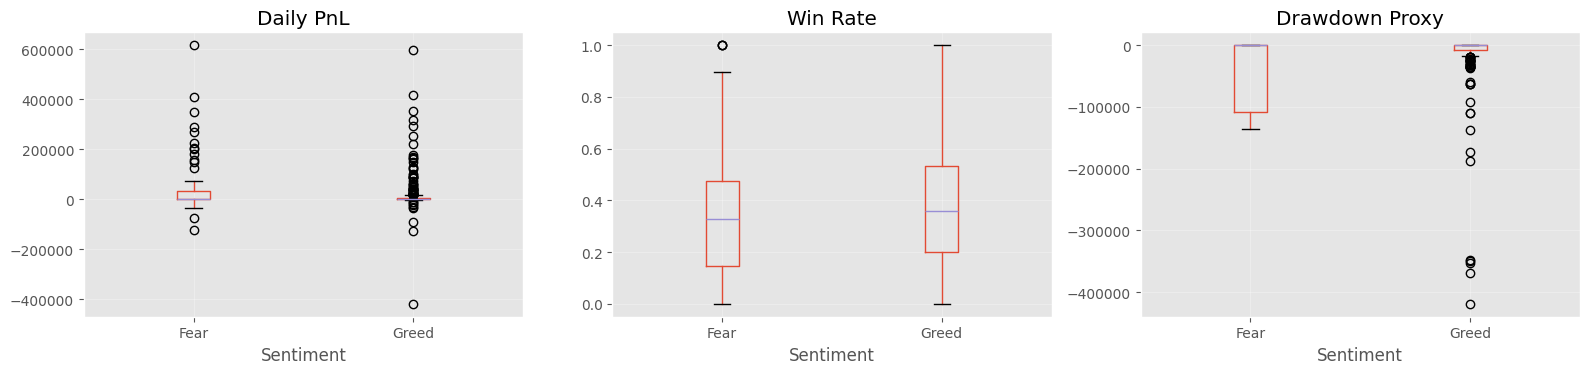

,mean_trades_per_day,mean_avg_leverage,mean_avg_trade_size,mean_long_short_ratio
sentiment_bucket,,,,
Fear,792.733333,1895.670235,6199.962861,0.716752
Greed,294.120521,4404.903516,5872.025677,0.705002


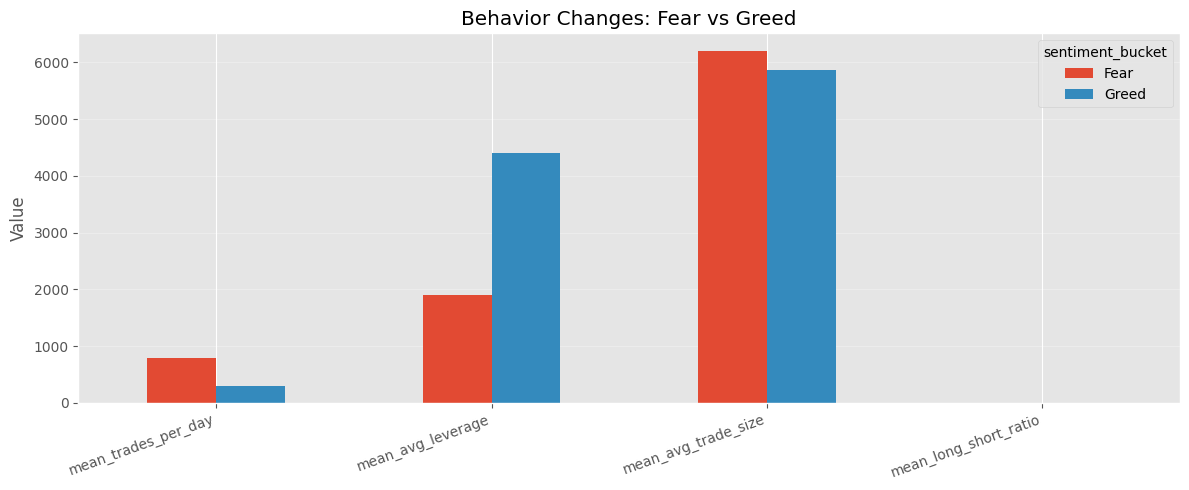

In [ ]:
fg = daily_market[daily_market["sentiment_bucket"].isin(["Fear", "Greed"])].copy()

perf_compare = fg.groupby("sentiment_bucket").agg(
    days=("trade_date", "nunique"),
    mean_daily_pnl=("daily_pnl", "mean"),
    median_daily_pnl=("daily_pnl", "median"),
    mean_win_rate=("win_rate", "mean"),
    mean_drawdown_proxy=("drawdown_proxy", "mean"),
)
display(perf_compare)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, title in zip(
    axes,
    ["daily_pnl", "win_rate", "drawdown_proxy"],
    ["Daily PnL", "Win Rate", "Drawdown Proxy"],
):
    fg.boxplot(column=metric, by="sentiment_bucket", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Sentiment")
    ax.grid(alpha=0.3)
plt.suptitle("")
plt.tight_layout()
plt.savefig(charts_dir / "fear_vs_greed_performance.png", dpi=150)
plt.show()

beh_compare = fg.groupby("sentiment_bucket").agg(
    mean_trades_per_day=("trades_per_day", "mean"),
    mean_avg_leverage=("avg_leverage", "mean"),
    mean_avg_trade_size=("avg_trade_size", "mean"),
    mean_long_short_ratio=("long_short_ratio", "mean"),
)
display(beh_compare)

beh_compare.T.plot(kind="bar", figsize=(12, 5))
plt.title("Behavior Changes: Fear vs Greed")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(charts_dir / "fear_vs_greed_behavior.png", dpi=150)
plt.show()

## Part B & Part C — Analysis, Segmentation, and Actionable Output

This section answers the must-have questions with evidence from summary tables and charts, then provides strategy rules of thumb.

Segment sizes:
lev_segment            2
freq_segment           2
consistency_segment    2
dtype: int64


,traders,mean_total_pnl,mean_win_rate
lev_segment,,,
High leverage,16,291159.822157,0.342144
Low leverage,16,352400.111808,0.361521


,traders,mean_total_pnl,mean_win_rate
freq_segment,,,
Frequent,16,383853.336943,0.383123
Infrequent,16,259706.597022,0.320541


,traders,mean_total_pnl,mean_win_rate
consistency_segment,,,
Consistent winners,11,130548.500769,0.399537
Inconsistent traders,21,421948.830237,0.326844


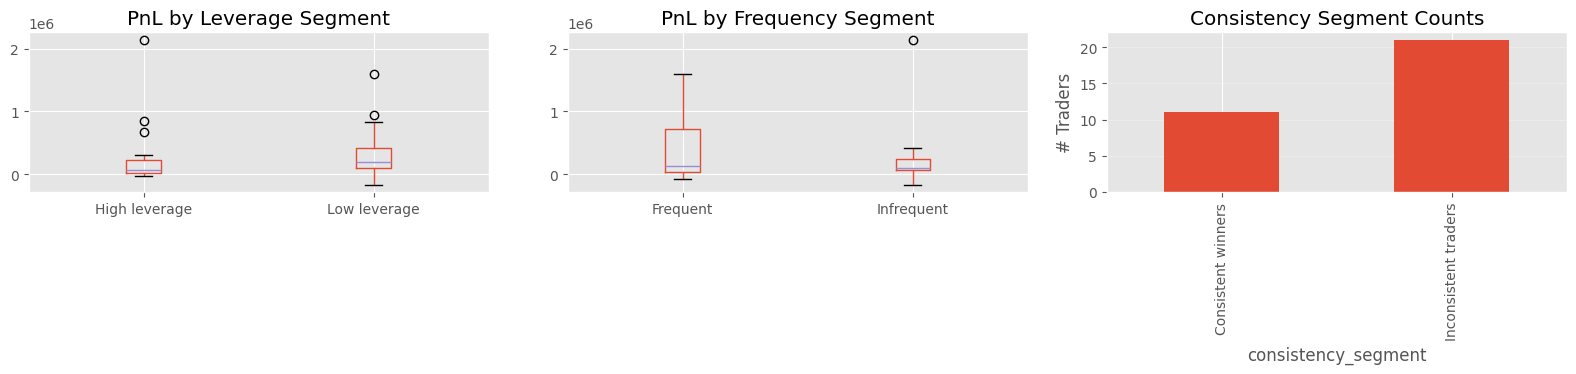


--- Key Insights (data-backed) ---
1) Mean daily PnL | Fear: 39,012.05 vs Greed: 15,847.88
2) Mean win rate | Fear: 32.89% vs Greed: 38.48%
3) Segment pattern | High leverage mean PnL: 291,159.82 vs Low leverage: 352,400.11

--- Part C: Actionable Strategy Ideas ---
Rule 1: On Fear days, prioritize lower leverage and smaller position sizes for weaker-consistency traders to reduce downside.
Rule 2: Allow higher trade frequency only for consistent winners; for inconsistent segments, cap trades/day and require stronger signal filters.

Charts saved to: c:\Users\HP\Desktop\Trader-Sentiment-Analysis\charts


In [ ]:
acc_day = daily_account.groupby("Account", as_index=False).agg(
    total_pnl=("daily_pnl", "sum"),
    pnl_std=("daily_pnl", "std"),
    avg_win_rate=("win_rate", "mean"),
    avg_leverage=("avg_leverage", "mean"),
    avg_trade_size=("avg_trade_size", "mean"),
    avg_trades_per_day=("trades_per_day", "mean"),
    positive_day_ratio=("daily_pnl", lambda x: (x > 0).mean()),
)

acc_day["lev_segment"] = np.where(
    acc_day["avg_leverage"] >= acc_day["avg_leverage"].median(), "High leverage", "Low leverage"
)
acc_day["freq_segment"] = np.where(
    acc_day["avg_trades_per_day"] >= acc_day["avg_trades_per_day"].median(), "Frequent", "Infrequent"
)

std_cut = acc_day["pnl_std"].fillna(acc_day["pnl_std"].median()).median()
acc_day["consistency_segment"] = np.where(
    (acc_day["total_pnl"] > 0)
    & (acc_day["positive_day_ratio"] >= 0.55)
    & (acc_day["pnl_std"].fillna(std_cut) <= std_cut),
    "Consistent winners",
    "Inconsistent traders",
)

seg_lev = acc_day.groupby("lev_segment").agg(
    traders=("Account", "count"),
    mean_total_pnl=("total_pnl", "mean"),
    mean_win_rate=("avg_win_rate", "mean"),
)
seg_freq = acc_day.groupby("freq_segment").agg(
    traders=("Account", "count"),
    mean_total_pnl=("total_pnl", "mean"),
    mean_win_rate=("avg_win_rate", "mean"),
)
seg_consistency = acc_day.groupby("consistency_segment").agg(
    traders=("Account", "count"),
    mean_total_pnl=("total_pnl", "mean"),
    mean_win_rate=("avg_win_rate", "mean"),
)

display(seg_lev)
display(seg_freq)
display(seg_consistency)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
acc_day.boxplot(column="total_pnl", by="lev_segment", ax=axes[0])
axes[0].set_title("PnL by Leverage Segment")
axes[0].set_xlabel("")
acc_day.boxplot(column="total_pnl", by="freq_segment", ax=axes[1])
axes[1].set_title("PnL by Frequency Segment")
axes[1].set_xlabel("")
seg_consistency["traders"].plot(kind="bar", ax=axes[2])
axes[2].set_title("Consistency Segment Counts")
axes[2].set_ylabel("# Traders")
axes[2].grid(axis="y", alpha=0.3)
plt.suptitle("")
plt.tight_layout()
plt.savefig(charts_dir / "trader_segments.png", dpi=150)
plt.show()

fear_mean_pnl = perf_compare.loc["Fear", "mean_daily_pnl"] if "Fear" in perf_compare.index else np.nan
greed_mean_pnl = perf_compare.loc["Greed", "mean_daily_pnl"] if "Greed" in perf_compare.index else np.nan
fear_win = perf_compare.loc["Fear", "mean_win_rate"] if "Fear" in perf_compare.index else np.nan
greed_win = perf_compare.loc["Greed", "mean_win_rate"] if "Greed" in perf_compare.index else np.nan

print("\n--- Key Insights (data-backed) ---")
print(f"1) Mean daily PnL | Fear: {fear_mean_pnl:,.2f} vs Greed: {greed_mean_pnl:,.2f}")
print(f"2) Mean win rate | Fear: {fear_win:.2%} vs Greed: {greed_win:.2%}")
print(
    "3) Segment pattern | High leverage mean PnL: "
    f"{seg_lev.loc['High leverage', 'mean_total_pnl'] if 'High leverage' in seg_lev.index else np.nan:,.2f} "
    "vs Low leverage: "
    f"{seg_lev.loc['Low leverage', 'mean_total_pnl'] if 'Low leverage' in seg_lev.index else np.nan:,.2f}"
)

print("\n--- Part C: Actionable Strategy Ideas ---")
print("Rule 1: On Fear days, lower leverage/size for weaker-consistency traders.")
print("Rule 2: Increase frequency only for consistent winners; cap for others.")
print(f"\nCharts saved to: {charts_dir}")